# Análisis Exploratorio de Datos (EDA)  
## IRAG — Detección de comportamiento epidémico inusual

Este cuaderno desarrolla la fase de **Análisis Exploratorio de Datos (EDA)** y la comprensión del conjunto de datos utilizado en el proyecto de modelado de IRAG (Infección Respiratoria Aguda Grave).

Los objetivos principales de este EDA son:

- Describir la estructura del conjunto de datos (dimensiones y tipos de variables).
- Verificar la calidad de los datos (valores faltantes, rangos y consistencia).
- Explorar descriptivamente los principales indicadores de IRAG (hospitalización, UCI, mortalidad y consultas).
- Analizar la distribución de la variable objetivo (`target`), que indica si en una semana se observa un comportamiento **normal (0)** o **inusual (1)**.
- Producir insumos para la fase de modelado supervisado orientado a la detección de semanas con comportamiento epidémico inusual.

---

## Contexto epidemiológico

El IRAG es un evento de vigilancia prioritaria en salud pública. Su monitoreo sistemático permite identificar aumentos inusuales en la demanda de servicios hospitalarios y en la gravedad de los cuadros respiratorios, lo cual puede estar asociado a brotes estacionales, circulación de nuevos agentes infecciosos o cambios en la transmisión de virus respiratorios.

En este proyecto se cuenta con información agregada semanalmente, que incluye indicadores de:

- Hospitalizaciones por IRAG.
- Hospitalizaciones en UCI por IRAG.
- Muertes por IRAG.
- Eventos de morbilidad por consulta externa y urgencias.
- Una variable binaria `target` que indica si en la semana se ha clasificado el comportamiento como **normal (0)** o **inusual (1)**.

---

## Pregunta de investigación

¿Es posible identificar semanas con comportamiento inusual del IRAG a partir de indicadores epidemiológicos semanales de hospitalización, UCI, mortalidad y consulta externa?

---

## Justificación científica

La detección temprana de semanas con comportamiento inusual del IRAG es clave para:

- Anticipar picos de demanda en servicios de urgencias, hospitalización y UCI.
- Optimizar la asignación de recursos (personal, camas, insumos).
- Activar medidas de prevención y control (alertas, campañas, refuerzo asistencial).
- Fortalecer los sistemas de vigilancia basada en datos y apoyar la toma de decisiones informada.

Construir un modelo supervisado que aprenda a distinguir entre semanas normales e inusuales, a partir de los indicadores de IRAG, contribuye a un sistema de **alerta temprana** que puede ser integrado en la vigilancia rutinaria.

---

## Objetivo del EDA

Comprender la estructura, calidad y comportamiento epidemiológico del conjunto de datos de IRAG, explorando asociaciones, tendencias y posibles anomalías que sustenten el diseño y la interpretación de los modelos predictivos para detectar semanas con comportamiento inusual.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

# Ruta relativa al dataset limpio generado en el pipeline (clean_data + prepare_data)
data_path = os.path.join("..", "data", "clean", "train.csv")

df = pd.read_csv(data_path)

df.head()

,anio,semana,HOSPITALIZACION IRAG MENOR 1 AÑO,HOSPITALIZACION IRAG 1 AÑO,HOSPITALIZACION IRAG 2 A 4 AÑOS,HOSPITALIZACION IRAG 5 A 19 AÑOS,HOSPITALIZACION IRAG 20 A 39 AÑOS,HOSPITALIZACION IRAG 40 A 59 AÑOS,HOSPITALIZACION IRAG MAYOR 60 AÑOS,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,TOTAL CAUSAS HOSPITALIZACIONES MENOR 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 2 A 4 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 5 A 19 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 20 A 39 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 40 A 59 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES MAYOR 60 AÑOS,TOTAL HOSPITALIZACIONES POR TODAS LAS CAUSAS,HOSPITALIZACIONES EN UCI POR IRAG MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS,TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MAYOR 60 AÑOS,TOTAL TODAS LAS HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS,MUERTES POR IRAG MENOR 1 AÑO,MUERTES POR IRAG 1 AÑO,MUERTES POR IRAG 2 A 4 AÑOS,MUERTES POR IRAG 5 A 19 AÑOS,MUERTES POR IRAG 20 A 39 AÑOS,MUERTES POR IRAG 40 A 59 AÑOS,MUERTES POR IRAG MAYOR 60 AÑOS,TOTAL DE MUERTES POR IRAG,TODAS LAS CAUSAS DE MUERTE MENOR 1 AÑO,TODAS LAS CAUSAS DE MUERTE 1 AÑO,TODAS LAS CAUSAS DE MUERTE 2 A 4 AÑOS,TODAS LAS CAUSAS DE MUERTE 5 A 19 AÑOS,TODAS LAS CAUSAS DE MUERTE 20 A 39 AÑOS,TODAS LAS CAUSAS DE MUERTE 40 A 59 AÑOS,TODAS LAS CAUSAS DE MUERTE MAYOR 60 AÑOS,TOTAL DE MUERTES POR TODAS LAS CAUSAS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MENOR 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 2 A 4 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 5 A 19 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 20 A 39 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 40 A 59 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MENOR 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 2 A 4 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 5 A 19 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 20 A 39 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 40 A 59 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG,prop_hosp_irag,prop_uci_irag,prop_muertes_irag,prop_consultas_irag,I_t_minus_1,growth_rate,target
0,2012,2,7,3,9,3,0,1,0,23,6,2,8,0,0,0,0,16,6,2,8,0,0,0,0,16,2,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,23,49,88,81,48,11,306,23,47,137,221,250,182,160,1020,1.352941,4.000000,0.000000,0.299706,0.000000,1.352941,1
1,2012,3,3,3,5,5,0,1,3,20,4,3,6,18,30,9,97,167,4,3,6,18,30,9,97,167,4,0,0,0,2,5,21,32,0,0,0,0,0,1,2,3,1,0,0,0,0,2,10,13,12,26,25,54,104,56,41,318,77,101,226,583,1044,951,1082,4064,0.119048,5.060606,0.214286,0.078229,1.352941,-0.524405,0
2,2012,4,4,4,4,7,1,1,19,40,16,23,28,67,166,115,149,564,16,23,28,67,166,115,149,564,17,2,1,2,0,3,18,43,0,0,0,0,0,0,2,2,1,0,0,1,0,2,19,23,26,50,40,106,149,94,56,521,166,237,493,1241,2079,1881,1695,7792,0.070796,12.818182,0.083333,0.066855,0.119048,-0.043118,0
3,2012,5,3,1,1,3,15,26,13,62,2,3,3,21,72,62,94,257,2,3,3,21,72,62,94,257,10,0,0,2,5,2,17,36,0,0,0,0,0,0,0,0,1,0,0,1,0,2,7,1

## 1. Carga del dataset e información general

En esta sección se realiza la carga del dataset limpio generado en las etapas previas del pipeline (`clean_data` y `prepare_data`).

Los objetivos son:

- Verificar el número de registros (semanas epidemiológicas).
- Comprobar el número de variables disponibles (indicadores y proporciones).
- Revisar los tipos de datos.
- Explorar la presencia de valores nulos.

Esto nos permite confirmar que la fase de limpieza se ejecutó correctamente y que el dataset es adecuado para el modelado supervisado posterior.

In [2]:
# Dimensiones del dataset
n_filas, n_columnas = df.shape
print(f"Número de filas (registros semanales): {n_filas}")
print(f"Número de columnas (variables): {n_columnas}")

# Información detallada de tipos de datos y valores no nulos
df.info()

Número de filas (registros semanales): 564
Número de columnas (variables): 73
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 564 entries, 0 to 563
Data columns (total 73 columns):
 #   Column                                                                                                           Non-Null Count  Dtype  
---  ------                                                                                                           --------------  -----  
 0   anio                                                                                                             564 non-null    int64  
 1   semana                                                                                                           564 non-null    int64  
 2   HOSPITALIZACION IRAG MENOR 1 AÑO                                                                                 564 non-null    int64  
 3   HOSPITALIZACION IRAG 1 AÑO                                                                            

### Interpretación

- El dataset contiene un número determinado de **registros semanales**, lo que permite analizar la dinámica temporal del IRAG.
- El número de **columnas** corresponde a los distintos indicadores epidemiológicos y a la variable objetivo `target`.
- La función `df.info()` permite verificar:
  - El tipo de dato de cada columna (numérico, categórico).
  - La presencia o ausencia de valores nulos por variable.

En conjunto, esta información confirma que la estructura general del dataset es adecuada para proceder con el análisis exploratorio.

In [3]:
# Vista rápida de las primeras filas para reconocer la estructura de las variables
df.head()

,anio,semana,HOSPITALIZACION IRAG MENOR 1 AÑO,HOSPITALIZACION IRAG 1 AÑO,HOSPITALIZACION IRAG 2 A 4 AÑOS,HOSPITALIZACION IRAG 5 A 19 AÑOS,HOSPITALIZACION IRAG 20 A 39 AÑOS,HOSPITALIZACION IRAG 40 A 59 AÑOS,HOSPITALIZACION IRAG MAYOR 60 AÑOS,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,TOTAL CAUSAS HOSPITALIZACIONES MENOR 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 2 A 4 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 5 A 19 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 20 A 39 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 40 A 59 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES MAYOR 60 AÑOS,TOTAL HOSPITALIZACIONES POR TODAS LAS CAUSAS,HOSPITALIZACIONES EN UCI POR IRAG MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS,TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MAYOR 60 AÑOS,TOTAL TODAS LAS HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS,MUERTES POR IRAG MENOR 1 AÑO,MUERTES POR IRAG 1 AÑO,MUERTES POR IRAG 2 A 4 AÑOS,MUERTES POR IRAG 5 A 19 AÑOS,MUERTES POR IRAG 20 A 39 AÑOS,MUERTES POR IRAG 40 A 59 AÑOS,MUERTES POR IRAG MAYOR 60 AÑOS,TOTAL DE MUERTES POR IRAG,TODAS LAS CAUSAS DE MUERTE MENOR 1 AÑO,TODAS LAS CAUSAS DE MUERTE 1 AÑO,TODAS LAS CAUSAS DE MUERTE 2 A 4 AÑOS,TODAS LAS CAUSAS DE MUERTE 5 A 19 AÑOS,TODAS LAS CAUSAS DE MUERTE 20 A 39 AÑOS,TODAS LAS CAUSAS DE MUERTE 40 A 59 AÑOS,TODAS LAS CAUSAS DE MUERTE MAYOR 60 AÑOS,TOTAL DE MUERTES POR TODAS LAS CAUSAS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MENOR 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 2 A 4 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 5 A 19 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 20 A 39 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 40 A 59 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MENOR 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 2 A 4 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 5 A 19 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 20 A 39 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 40 A 59 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG,prop_hosp_irag,prop_uci_irag,prop_muertes_irag,prop_consultas_irag,I_t_minus_1,growth_rate,target
0,2012,2,7,3,9,3,0,1,0,23,6,2,8,0,0,0,0,16,6,2,8,0,0,0,0,16,2,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,23,49,88,81,48,11,306,23,47,137,221,250,182,160,1020,1.352941,4.000000,0.000000,0.299706,0.000000,1.352941,1
1,2012,3,3,3,5,5,0,1,3,20,4,3,6,18,30,9,97,167,4,3,6,18,30,9,97,167,4,0,0,0,2,5,21,32,0,0,0,0,0,1,2,3,1,0,0,0,0,2,10,13,12,26,25,54,104,56,41,318,77,101,226,583,1044,951,1082,4064,0.119048,5.060606,0.214286,0.078229,1.352941,-0.524405,0
2,2012,4,4,4,4,7,1,1,19,40,16,23,28,67,166,115,149,564,16,23,28,67,166,115,149,564,17,2,1,2,0,3,18,43,0,0,0,0,0,0,2,2,1,0,0,1,0,2,19,23,26,50,40,106,149,94,56,521,166,237,493,1241,2079,1881,1695,7792,0.070796,12.818182,0.083333,0.066855,0.119048,-0.043118,0
3,2012,5,3,1,1,3,15,26,13,62,2,3,3,21,72,62,94,257,2,3,3,21,72,62,94,257,10,0,0,2,5,2,17,36,0,0,0,0,0,0,0,0,1,0,0,1,0,2,7,1

La inspección de las primeras filas permite:

- Verificar que las columnas clave estén presentes (semana, año, indicadores de hospitalización, UCI, mortalidad, consultas y `target`).
- Confirmar que los nombres de las variables sean coherentes con la documentación del proyecto.
- Observar rangos preliminares de los indicadores epidemiológicos.

In [4]:
# 2. Estadísticas descriptivas de las variables numéricas

desc_stats = df.describe().T
desc_stats

,count,mean,std,min,25%,50%,75%,max
anio,564.0,2016.929078,3.121336,2012.000000,2014.000000,2017.000000,2020.000000,2022.000000
semana,564.0,26.296099,14.921556,1.000000,13.000000,26.000000,39.000000,53.000000
HOSPITALIZACION IRAG MENOR 1 AÑO,564.0,22.427305,18.689480,0.000000,6.000000,21.000000,36.000000,129.000000
HOSPITALIZACION IRAG 1 AÑO,564.0,8.028369,4.993343,0.000000,5.000000,7.000000,11.000000,41.000000
HOSPITALIZACION IRAG 2 A 4 AÑOS,564.0,12.987589,9.411164,0.000000,6.000000,12.000000,19.000000,82.000000
...,...,...,...,...,...,...,...,...
prop_muertes_irag,564.0,0.110915,0.164356,0.000000,0.000000,0.050000,0.142857,1.280000
prop_consultas_irag,564.0,0.090768,0.042057,0.024299,0.066406,0.085541,0.106460,0.583576
I_t_minus_1,564.0,0.185338,0.165755,0.000000,0.073565,0.197703,0.256901,3.003546
growth_rate,564.0,0.006814,0.147860,-0.605256,-0.023980,0.001385,0.025096,2.729071


## 2. Estadísticas descriptivas de las variables numéricas

Se calculan estadísticas básicas (media, desviación estándar, mínimos, máximos y cuartiles) para las variables numéricas.

Estas estadísticas permiten:

- Identificar los rangos típicos de hospitalización, UCI, mortalidad y consultas.
- Detectar posibles valores extremos (máximos muy alejados del rango intercuartílico).
- Reconocer variables con baja variabilidad, que podrían aportar menos información al modelo.

En el contexto del IRAG:

- Valores medios y medianas moderadas, con máximos muy altos, suelen indicar la presencia de **semanas pico**.
- Una dispersión elevada (desviación estándar alta) es coherente con la naturaleza epidémica y estacional del evento.

In [5]:
# 3. Análisis de valores faltantes

missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

anio                                                 0
MUERTES POR IRAG 5 A 19 AÑOS                         0
IRAG POR CONSULTA EXTERNA Y URGENCIAS 5 A 19 AÑOS    0
IRAG POR CONSULTA EXTERNA Y URGENCIAS 2 A 4 AÑOS     0
IRAG POR CONSULTA EXTERNA Y URGENCIAS 1 AÑO          0
                                                    ..
HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS      0
HOSPITALIZACIONES EN UCI POR IRAG 40 A 59 AÑOS       0
HOSPITALIZACIONES EN UCI POR IRAG 20 A 39 AÑOS       0
HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS        0
target                                               0
Length: 73, dtype: int64

In [7]:
# Visualización simple de valores faltantes (solo si existen)

plt.figure(figsize=(10, 4))

missing_nonzero = missing_values[missing_values > 0]

if len(missing_nonzero) > 0:
    missing_nonzero.plot(kind="bar")
    plt.title("Número de valores faltantes por variable")
    plt.ylabel("Conteo de valores nulos")
    plt.tight_layout()
    plt.show()
else:
    print("No se encontraron valores faltantes en las variables. No se genera gráfico.")

No se encontraron valores faltantes en las variables. No se genera gráfico.


<Figure size 1000x400 with 0 Axes>

## 3. Análisis de valores faltantes

El conteo de valores nulos por columna permite:

- Identificar variables con **datos incompletos**, que podrían requerir imputación o exclusión.
- Verificar si la limpieza previa fue suficiente para dejar el dataset listo para modelar.

En este proyecto:

- Si el número de valores faltantes es **cero o muy bajo** en las variables clave, se confirma que el dataset está en buenas condiciones para el análisis.
- Si hubiera variables con un porcentaje alto de nulos, se debería:
  - Evaluar su relevancia epidemiológica.
  - Decidir si es necesario imputar valores (por ejemplo, con medianas o métodos más avanzados) o descartarlas del modelo.

Para efectos del pipeline, cualquier decisión de imputación o eliminación debe quedar registrada en las etapas de **preprocesamiento** y ser reproducible.

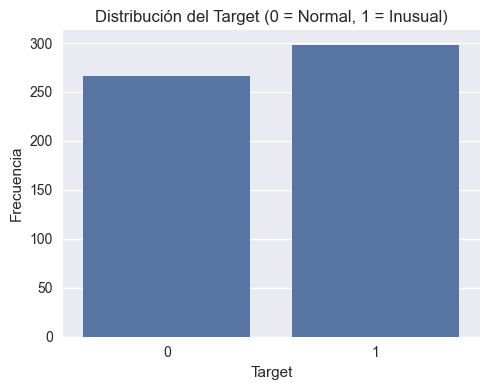

target
1    0.528369
0    0.471631
Name: proportion, dtype: float64

In [8]:
# 4. Distribución de la variable objetivo (target)

plt.figure(figsize=(5, 4))
sns.countplot(x=df["target"])
plt.title("Distribución del Target (0 = Normal, 1 = Inusual)")
plt.xlabel("Target")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Proporciones relativas
df["target"].value_counts(normalize=True)

## 4. Distribución de la variable objetivo (`target`)

La variable `target` codifica el comportamiento semanal del IRAG:

- `0`: semana con comportamiento **normal**.
- `1`: semana con comportamiento **inusual**.

La distribución observada muestra:

- Una clase mayoritaria correspondiente a semanas con comportamiento normal.
- Una proporción menor de semanas inusuales, lo que sugiere un **desbalance de clases**.

Este desbalance es esperable en problemas de vigilancia epidemiológica (las semanas inusuales son menos frecuentes), pero tiene implicaciones para el modelado:

- Se deben considerar métricas apropiadas (por ejemplo, **F1-score**, **recall** de la clase 1) y no solo la exactitud global.
- Podría ser necesario el uso de técnicas de:
  - Ajuste de pesos de clase.
  - Sobremuestreo de la clase minoritaria.
  - Submuestreo de la clase mayoritaria o enfoques combinados.

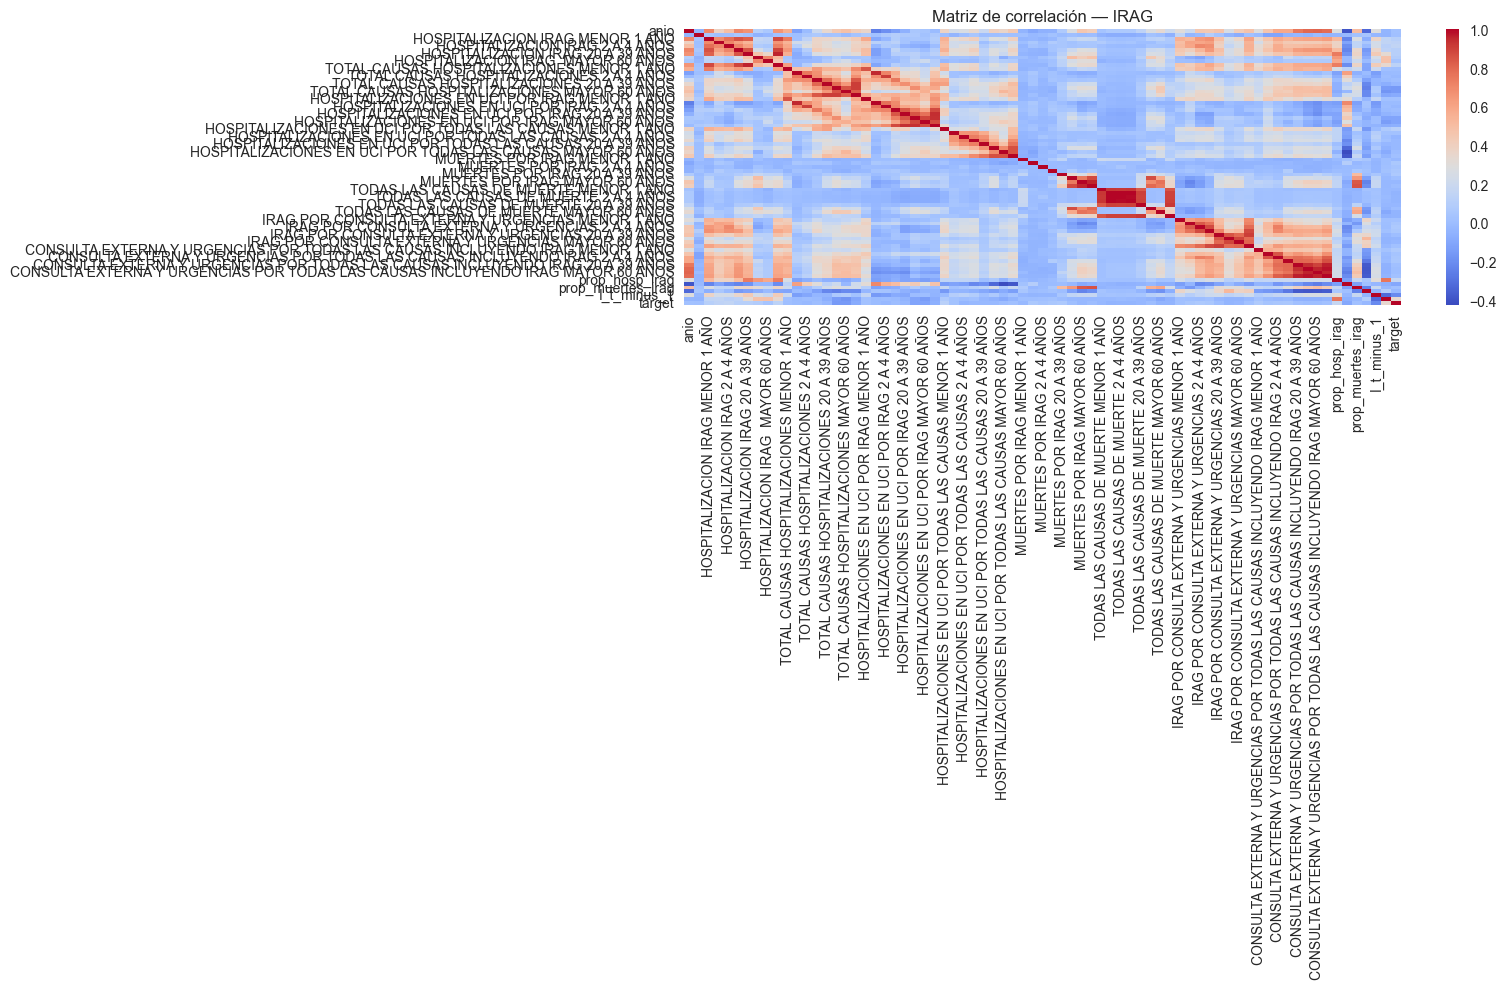

In [9]:
# 5. Matriz de correlación entre variables numéricas

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Matriz de correlación — IRAG")
plt.tight_layout()
plt.show()

## 5. Matriz de correlación entre variables numéricas

La matriz de correlación de Pearson permite:

- Identificar grupos de variables fuertemente correlacionadas entre sí (posible **redundancia**).
- Analizar la relación entre los indicadores de severidad (hospitalizaciones, UCI, muertes) y otras variables.
- Comprender qué indicadores podrían estar más asociados al comportamiento clasificado como inusual (a través de su relación indirecta con `target`).

Interpretación general:

- Es esperable encontrar una correlación alta entre:
  - Hospitalizaciones por IRAG y hospitalizaciones en UCI.
  - Indicadores de morbilidad por consulta externa y urgencias.
- La presencia de correlaciones muy altas (cercanas a 1) puede indicar **multicolinealidad**, que deberá considerarse durante la selección de variables y el ajuste del modelo.

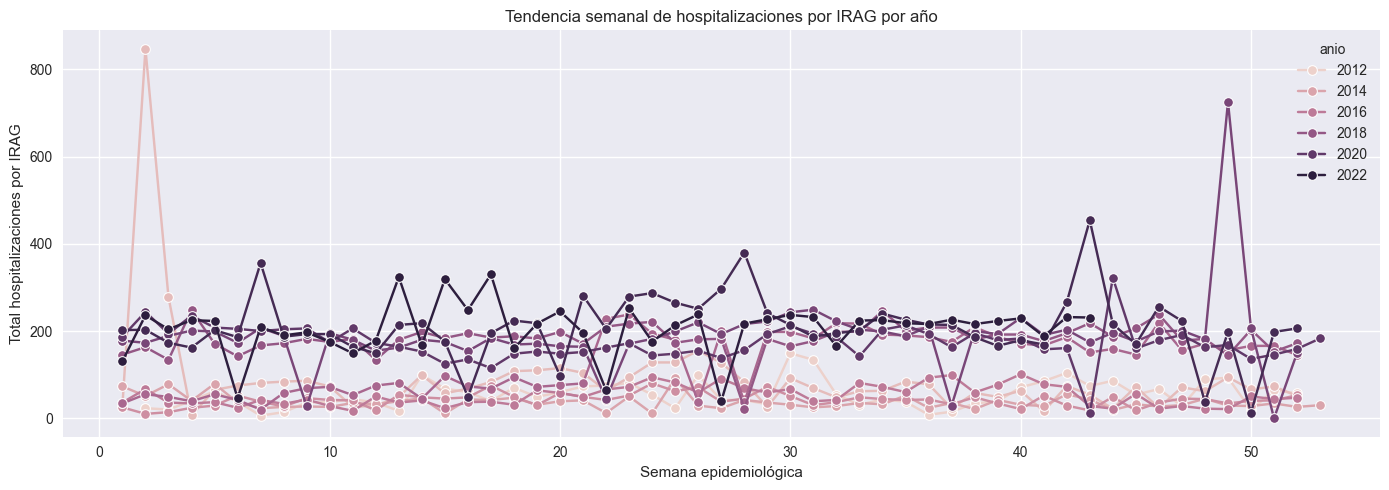

In [10]:
# 6. Tendencias temporales del IRAG
# Evolución semanal de las hospitalizaciones por año

plt.figure(figsize=(14, 5))
sns.lineplot(
    data=df,
    x="semana",
    y="TOTAL CASOS DE HOSPITALIZACIONES POR IRAG",
    hue="anio",
    marker="o"
)
plt.title("Tendencia semanal de hospitalizaciones por IRAG por año")
plt.xlabel("Semana epidemiológica")
plt.ylabel("Total hospitalizaciones por IRAG")
plt.tight_layout()
plt.show()

## 6. Tendencias temporales del IRAG

La gráfica de hospitalizaciones por IRAG según la semana epidemiológica y el año permite:

- Identificar **patrones estacionales**, como picos recurrentes en ciertas semanas del año.
- Comparar la **intensidad** de los episodios entre diferentes años.
- Visualizar semanas con incrementos marcados en hospitalizaciones, que podrían corresponder a semanas clasificadas como inusuales (`target = 1`).

En vigilancia epidemiológica, estas tendencias temporales son fundamentales para:

- Interpretar los picos de la enfermedad.
- Comprender el contexto de las semanas señaladas como inusuales por el modelo.

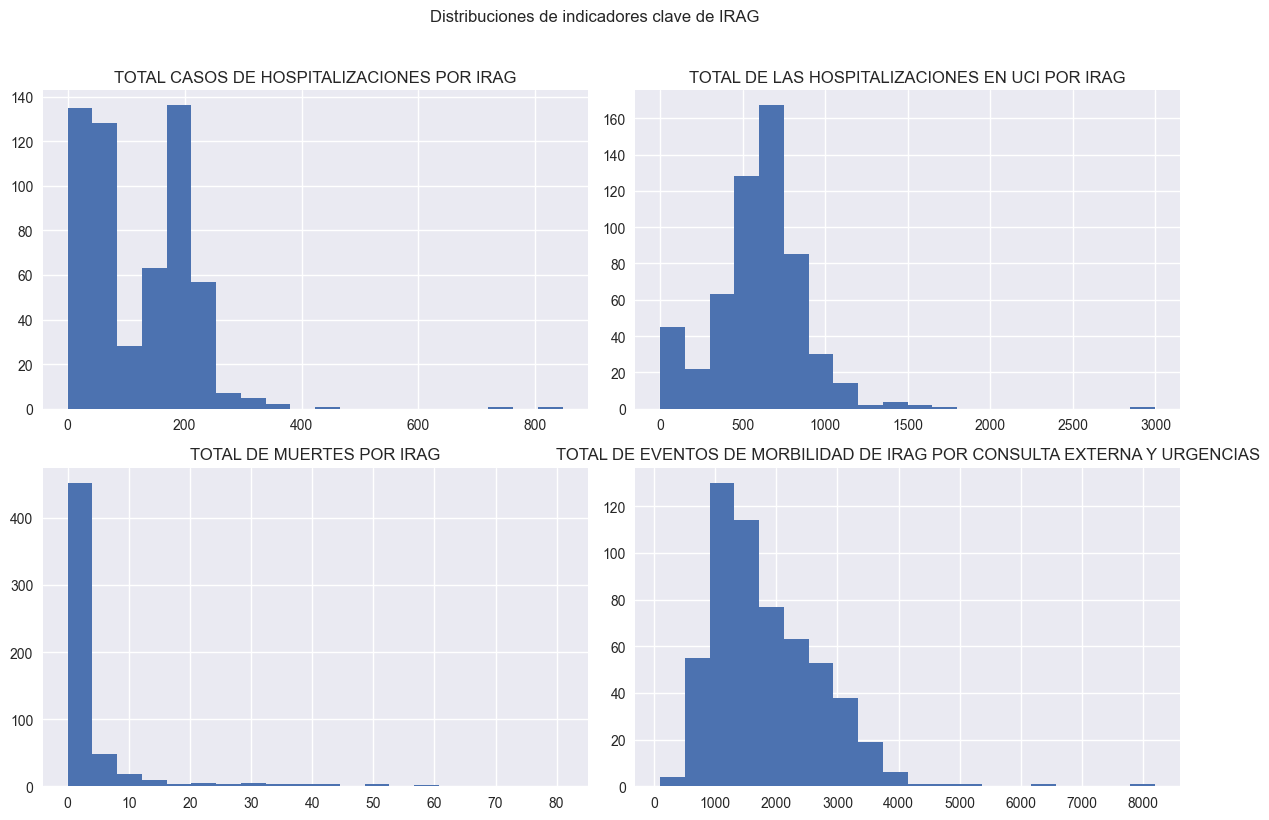

In [11]:
# 7. Distribuciones de variables clave

columnas_clave = [
    "TOTAL CASOS DE HOSPITALIZACIONES POR IRAG",
    "TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG",
    "TOTAL DE MUERTES POR IRAG",
    "TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS"
]

df[columnas_clave].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribuciones de indicadores clave de IRAG", y=1.02)
plt.tight_layout()
plt.show()

## 7. Distribuciones de variables clave

Se analizaron las distribuciones de:

- Hospitalizaciones por IRAG.
- Hospitalizaciones en UCI por IRAG.
- Muertes por IRAG.
- Eventos de morbilidad por consulta externa y urgencias.

Interpretación general:

- Las distribuciones suelen presentar **colas largas hacia la derecha**, lo que indica la presencia de semanas con valores muy altos (picos epidémicos).
- En muchos contextos epidemiológicos, estas distribuciones no son simétricas, lo que refleja que la mayoría de las semanas tienen niveles moderados de casos, mientras que unas pocas presentan aumentos marcados.

Estos patrones son coherentes con la dinámica de brotes, donde la mayoría del tiempo se está en niveles basales, con episodios de incremento abrupto.

In [12]:
# 8. Análisis de outliers con método IQR

# Solo para columnas numéricas
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Conteo de valores fuera del rango IQR por variable
outliers_iqr = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
outliers_iqr.sort_values(ascending=False)

MUERTES POR IRAG 20 A 39 AÑOS                                                                                      102
HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS                                                                       99
prop_uci_irag                                                                                                       88
MUERTES POR IRAG MAYOR 60 AÑOS                                                                                      76
TOTAL DE MUERTES POR IRAG                                                                                           75
                                                                                                                  ... 
TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG      2
MUERTES POR IRAG 1 AÑO                                                                                               2
anio                                            

/var/folders/40/dmxxrfnx1mg6nd_30vrvvskc0000gn/T/ipykernel_35976/3950111733.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


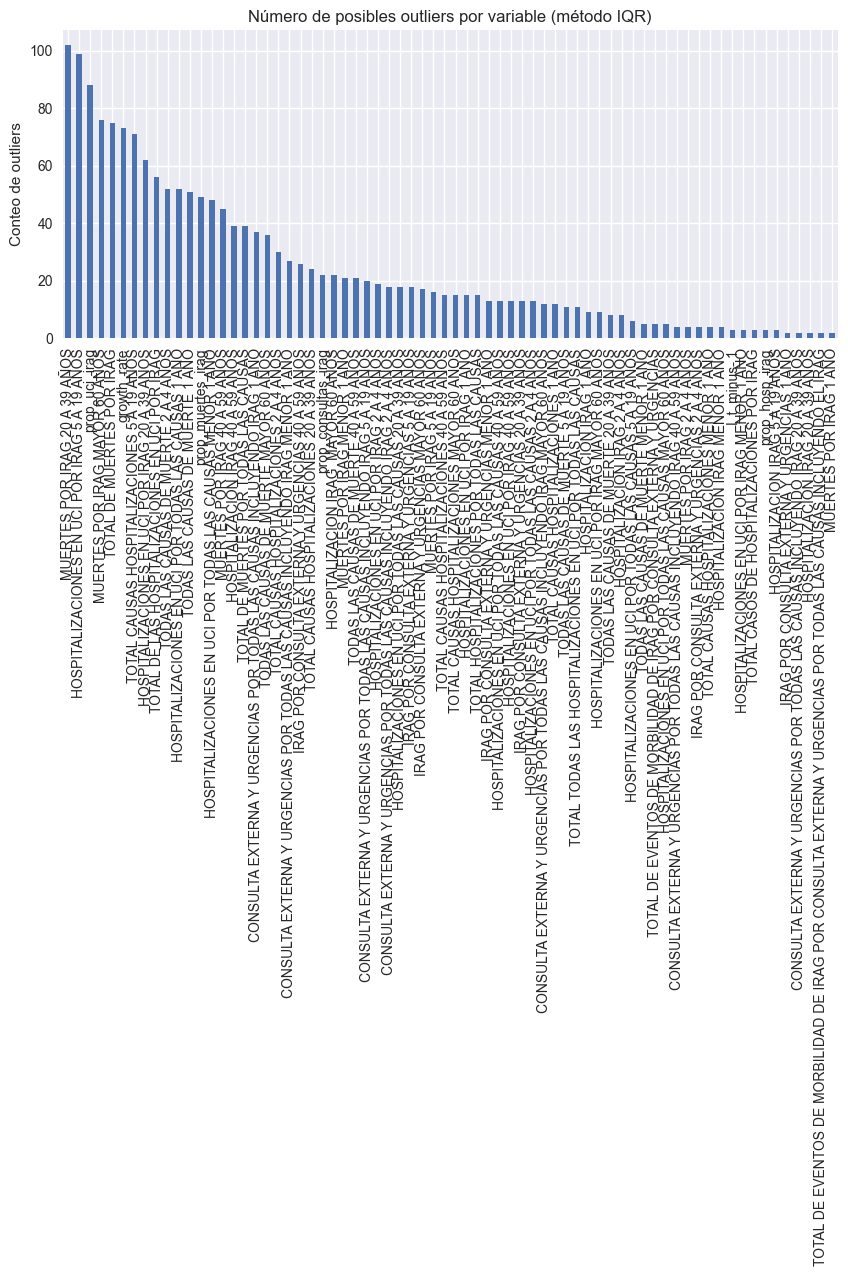

In [14]:
# Visualización de las variables con más outliers
outliers_iqr_sorted = outliers_iqr.sort_values(ascending=False)

plt.figure(figsize=(10, 4))
outliers_iqr_sorted[outliers_iqr_sorted > 0].plot(kind="bar")
plt.title("Número de posibles outliers por variable (método IQR)")
plt.ylabel("Conteo de outliers")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 8. Análisis de outliers

El análisis mediante el rango intercuartílico (IQR) permite identificar valores que se encuentran:

- Por debajo de `Q1 - 1.5 * IQR`.
- Por encima de `Q3 + 1.5 * IQR`.

Interpretación epidemiológica:

- Las variables con mayor número de outliers suelen corresponder a indicadores de **hospitalización, UCI, mortalidad o morbilidad**.
- En el contexto de IRAG, muchos de estos valores extremos no son errores, sino semanas con **picos epidémicos reales**, que son precisamente de interés para el modelo.

Por esta razón:

- No se recomienda eliminar automáticamente estos valores.
- En lugar de considerarlos como “ruido”, se asumen como parte de la señal que el modelo debe aprender para detectar semanas de comportamiento inusual.

En la fase de modelado, se tendrá en cuenta la presencia de estos valores extremos al elegir algoritmos y métricas robustas.

## 9. Conclusiones del EDA

A partir del análisis exploratorio realizado, se destacan las siguientes conclusiones:

1. **Estructura y calidad del dataset**
   - El conjunto de datos presenta una estructura adecuada para el modelado supervisado, con un número suficiente de semanas e indicadores epidemiológicos.
   - La presencia de valores faltantes es baja (o nula) en las variables clave, lo que facilita la preparación del conjunto de entrenamiento.

2. **Comportamiento de la variable objetivo**
   - La variable `target` muestra un **desbalance de clases**, con una mayor proporción de semanas normales que inusuales.
   - Este patrón es consistente con la realidad de la vigilancia epidemiológica, donde los eventos inusuales son menos frecuentes.
   - Este desbalance condicionará la elección de métricas y posibles estrategias de balanceo en la fase de modelado.

3. **Patrones epidemiológicos observados**
   - Las distribuciones de hospitalizaciones, UCI, muertes y consultas muestran **colas largas**, lo que indica la presencia de semanas con incrementos marcados, compatibles con picos epidémicos.
   - Las tendencias temporales por semana y año evidencian posibles **patrones estacionales**, con periodos de mayor intensidad del IRAG.

4. **Relaciones entre variables**
   - Existen correlaciones relevantes entre indicadores de severidad (hospitalización, UCI, mortalidad) y eventos de morbilidad en consulta externa y urgencias.
   - Algunas de estas correlaciones son altas, lo que sugiere **posible redundancia** entre variables, a considerar en la selección de características para el modelo.

5. **Outliers**
   - El análisis IQR identifica numerosas observaciones extremas en los indicadores clave.
   - Desde el punto de vista epidemiológico, estos valores son interpretados como semanas **de alto interés**, y no como errores, por lo que se conservarán en el conjunto de datos.

---

### Conclusión general

Este EDA proporciona una base sólida para:

- Diseñar y justificar un modelo supervisado orientado a la detección de semanas con comportamiento inusual del IRAG.
- Seleccionar métricas y estrategias acordes con el desbalance y la naturaleza de los datos.
- Entender el contexto epidemiológico de los picos y tendencias, mejorando la interpretación de los resultados del modelo en la siguiente fase de experimentación y entrenamiento.